# Placement Readiness Prediction System
### Using Gradient Boosting Regression

This notebook builds a machine learning model that predicts how ready a student is for campus placement.
The output is a score between 0 and 100 — the higher the score, the more placement-ready the student is.

We're using **Gradient Boosting** because it gave us the best results (R² ≈ 0.97) compared to other models we tested. It builds trees one by one, where each tree learns from the mistakes of the previous one — which makes it very good at capturing complex patterns in data.

The dataset has 500 students with 5 features:
- CGPA, DSA Score, Communication Skills, Internship Experience, Number of Projects

---

## 1. Importing the Libraries

Before anything else, we need to bring in all the tools we'll use throughout this notebook.
Think of this as setting up your workspace before starting a project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# For scaling the data
from sklearn.preprocessing import MinMaxScaler

# For splitting data into train and test sets, and cross validation
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# The model we're using
from sklearn.ensemble import GradientBoostingRegressor

# Regression metrics — measures how close predictions are to actual scores
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification metrics — measures how well we predict the readiness band (Excellent / Good / Average / Needs Improvement)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Loading the Dataset

We load the CSV file and take a first look at what the data looks like.

In [2]:
df = pd.read_csv('readiness_dataset.csv')

print(f"Dataset has {df.shape[0]} student records and {df.shape[1]} columns.")
print()
df.head(10)

Dataset has 500 student records and 6 columns.



,cgpa,dsa_score,communication_skills,internship_experience,projects,readiness_score
0,6.87,95,8.4,0,3,65.45
1,7.23,9,6.8,0,3,39.31
2,8.54,2,9.8,1,5,57.79
3,5.00,99,7.7,1,3,69.40
4,7.16,29,7.7,1,0,51.46
5,9.87,23,4.5,1,1,57.44
6,7.57,59,4.3,0,4,54.50
7,7.25,1,9.7,1,4,51.38
8,6.52,9,8.1,0,4,39.62
9,8.05,83,5.0,0,1,59.58


---
## 3. Understanding the Data (EDA)

Before jumping into building the model, it's important to actually understand what's in the dataset.
This section answers questions like:
- Are there any missing values?
- What does the target score look like — is it spread out or clustered?
- Which features actually have a strong relationship with the readiness score?

Skipping this step is one of the most common mistakes beginners make.

In [3]:
# Basic info — data types and missing values
print("Column data types:")
print(df.dtypes)
print()

print("Missing values in each column:")
print(df.isnull().sum())
print()

print("Summary statistics:")
df.describe().round(2)

Column data types:
cgpa                     float64
dsa_score                  int64
communication_skills     float64
internship_experience      int64
projects                   int64
readiness_score          float64
dtype: object

Missing values in each column:
cgpa                     0
dsa_score                0
communication_skills     0
internship_experience    0
projects                 0
readiness_score          0
dtype: int64

Summary statistics:


,cgpa,dsa_score,communication_skills,internship_experience,projects,readiness_score
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,7.45,50.09,6.90,0.52,2.55,56.99
std,1.44,30.03,1.70,0.50,1.74,11.53
min,5.00,0.00,4.00,0.00,0.00,27.92
25%,6.20,25.00,5.40,0.00,1.00,48.69
50%,7.44,52.00,6.95,1.00,3.00,57.36
75%,8.72,75.00,8.30,1.00,4.00,65.28
max,10.00,99.00,10.00,1.00,5.00,82.12


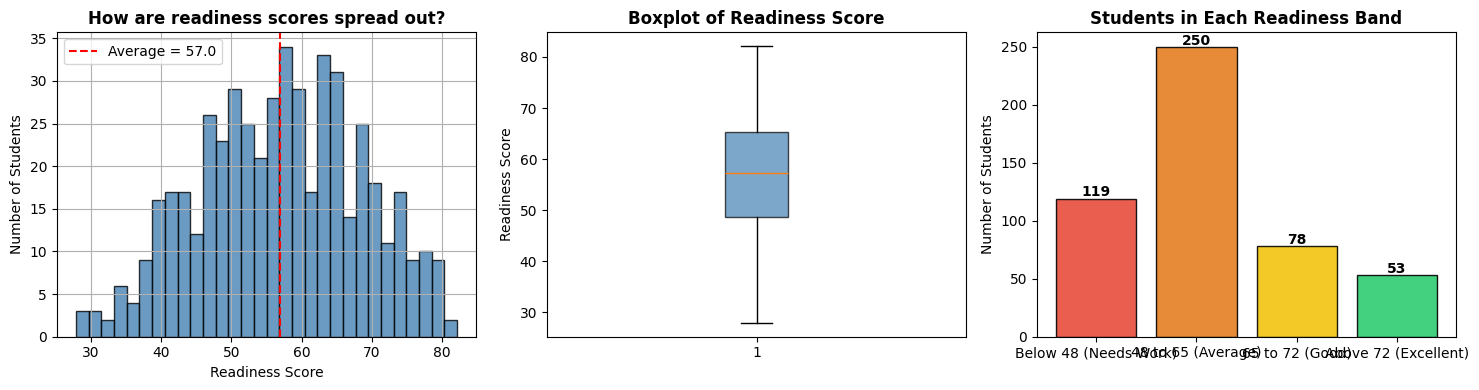

In [4]:
# Let's look at how the readiness score is distributed across students
# A good distribution should be roughly bell-shaped, not skewed to one side

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram — how many students fall in each score range
df['readiness_score'].hist(ax=axes[0], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('How are readiness scores spread out?', fontweight='bold')
axes[0].set_xlabel('Readiness Score')
axes[0].set_ylabel('Number of Students')
axes[0].axvline(df['readiness_score'].mean(), color='red', linestyle='--',
                label=f"Average = {df['readiness_score'].mean():.1f}")
axes[0].legend()

# Boxplot — gives a quick summary of median, spread, and outliers
axes[1].boxplot(df['readiness_score'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Readiness Score', fontweight='bold')
axes[1].set_ylabel('Readiness Score')

# Breaking scores into 4 readiness bands to see how many students fall in each
bands = [
    'Below 48 (Needs Work)',
    '48 to 65 (Average)',
    '65 to 72 (Good)',
    'Above 72 (Excellent)'
]
band_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
counts = [
    len(df[df['readiness_score'] < 48]),
    len(df[(df['readiness_score'] >= 48) & (df['readiness_score'] < 65)]),
    len(df[(df['readiness_score'] >= 65) & (df['readiness_score'] < 72)]),
    len(df[df['readiness_score'] >= 72])
]
axes[2].bar(bands, counts, color=band_colors, edgecolor='black', alpha=0.9)
axes[2].set_title('Students in Each Readiness Band', fontweight='bold')
axes[2].set_ylabel('Number of Students')
for bar, cnt in zip(axes[2].patches, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, cnt + 2,
                 str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

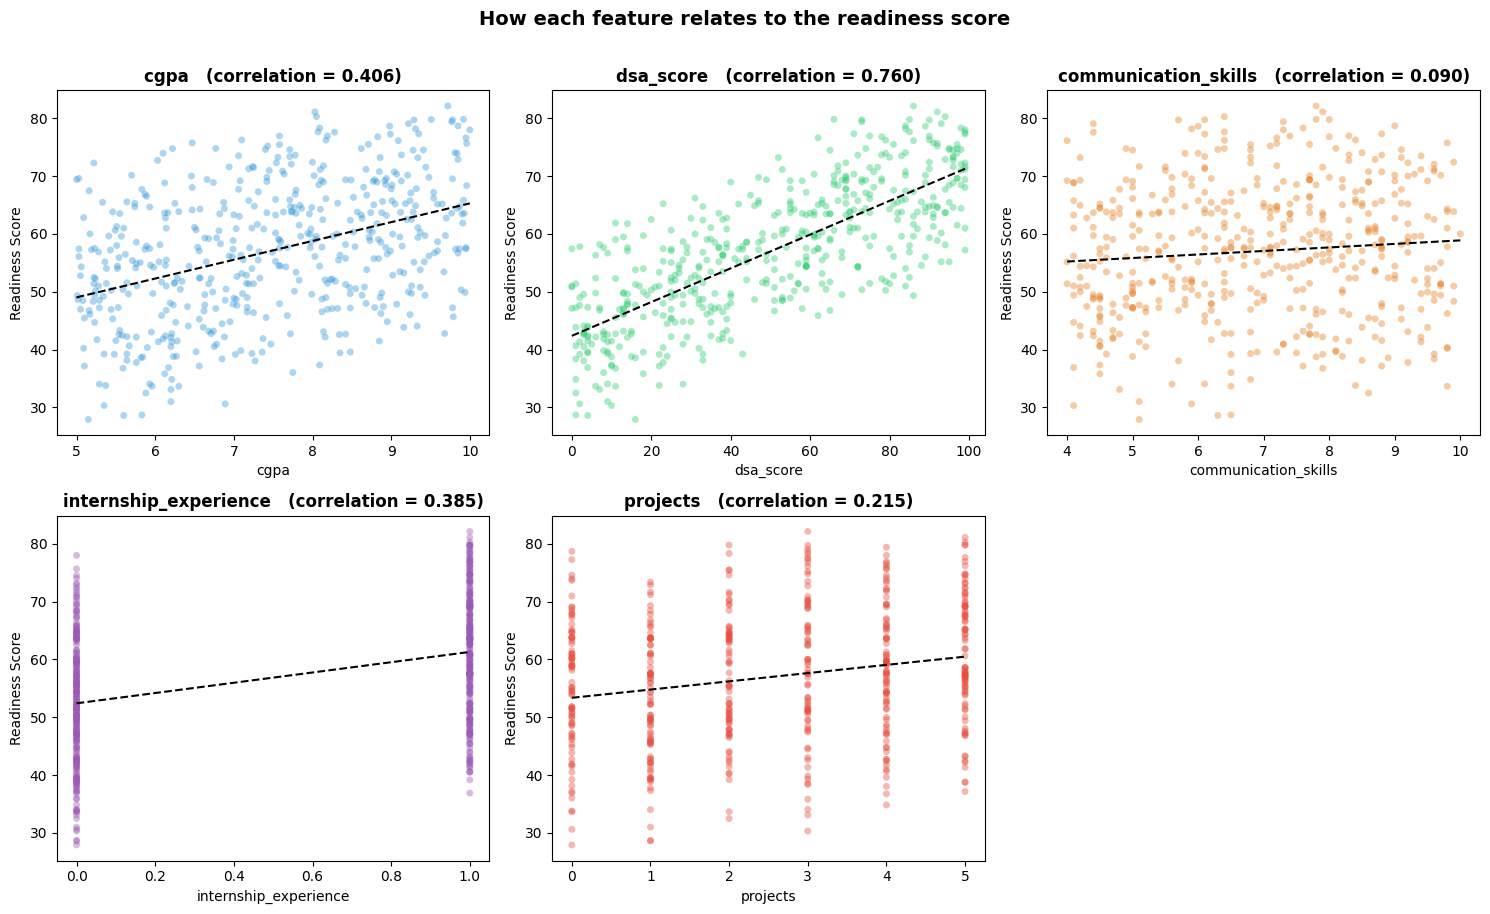

In [5]:
# Scatter plots — each feature vs the readiness score
# The tighter the points follow a diagonal, the stronger the relationship
# We also add a trend line to make the direction clearer

feature_cols = ['cgpa', 'dsa_score', 'communication_skills', 'internship_experience', 'projects']
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, c) in enumerate(zip(feature_cols, colors)):
    axes[i].scatter(df[col], df['readiness_score'],
                    alpha=0.4, color=c, edgecolors='none', s=25)
    # add a trend line so the direction is obvious
    z = np.polyfit(df[col], df['readiness_score'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'k--', lw=1.5)
    corr = df[col].corr(df['readiness_score'])
    axes[i].set_title(f'{col}   (correlation = {corr:.3f})', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Readiness Score')

axes[5].axis('off')
plt.suptitle('How each feature relates to the readiness score', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

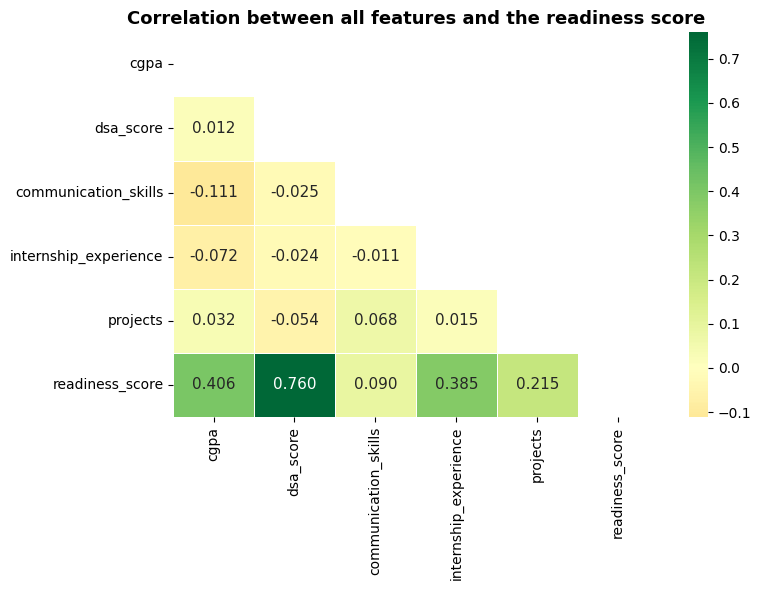

Correlation of each feature with readiness score (sorted by strength):
dsa_score                0.7599
cgpa                     0.4056
internship_experience    0.3854
projects                 0.2151
communication_skills     0.0897
Name: readiness_score, dtype: float64


In [6]:
# Correlation heatmap — shows all relationships in one chart
# Values close to 1 or -1 mean a strong relationship
# Values near 0 mean little to no relationship

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, mask=mask,
            annot_kws={'size': 11})
ax.set_title('Correlation between all features and the readiness score', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation of each feature with readiness score (sorted by strength):")
print(df.corr()['readiness_score'].drop('readiness_score').sort_values(ascending=False).round(4))

---
## 4. Preparing the Data for Training

The raw data can't go directly into the model — we need to clean it up and put it in the right format first.

**Steps we do here:**
1. Separate the features (inputs) from the target (what we want to predict)
2. Scale all features to the same range using MinMaxScaler
3. Split the data into training and testing sets

**Why scaling matters:**
DSA score goes from 0 to 99, while internship is just 0 or 1.
Without scaling, the model might think DSA is more important just because its numbers are bigger.
MinMaxScaler fixes this by bringing everything into the 0–1 range, so the model judges importance fairly.

In [7]:
# Step 1: Separate inputs (X) from the target we want to predict (y)
feature_cols = ['cgpa', 'dsa_score', 'communication_skills',
                'internship_experience', 'projects']

X = df[feature_cols].copy()
y = df['readiness_score'].copy()

print(f"Input features (X): {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target scores   (y): {y.shape[0]} values")
print(f"Score range: {y.min():.1f} to {y.max():.1f}")

Input features (X): 500 rows, 5 columns
Target scores   (y): 500 values
Score range: 27.9 to 82.1


In [8]:
# Step 2: Scale all features to the 0–1 range
# We fit the scaler on ALL the data here so it learns the full range of each feature
# The same scaler will be used when predicting new student scores later

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print("Before scaling — feature ranges:")
print(X.describe().loc[['min', 'max']].round(2))
print()
print("After scaling — all features now between 0 and 1:")
print(X_scaled.describe().loc[['min', 'max']].round(4))

Before scaling — feature ranges:
     cgpa  dsa_score  communication_skills  internship_experience  projects
min   5.0        0.0                   4.0                    0.0       0.0
max  10.0       99.0                  10.0                    1.0       5.0

After scaling — all features now between 0 and 1:
     cgpa  dsa_score  communication_skills  internship_experience  projects
min   0.0        0.0                   0.0                    0.0       0.0
max   1.0        1.0                   1.0                    1.0       1.0


In [9]:
# Step 3: Split into training set (80%) and test set (20%)
# The model will never see the test set during training
# This lets us check how well it performs on completely new data

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42
)

print(f"Training set : {X_train.shape[0]} students — the model learns from these")
print(f"Test set     : {X_test.shape[0]} students — used only for evaluation, never for training")

Training set : 400 students — the model learns from these
Test set     : 100 students — used only for evaluation, never for training


---
## 5. Building and Training the Gradient Boosting Model

Gradient Boosting works by building decision trees one at a time.
Each new tree focuses on correcting the errors the previous trees made.
Over 200 rounds of this, the model gets very good at predicting the readiness score.

**The key settings we use:**
- `n_estimators=200` — build 200 trees in sequence
- `max_depth=5` — each tree can go at most 5 levels deep, which prevents overfitting
- `learning_rate=0.05` — each tree contributes a small amount, making the learning more careful and stable
- `subsample=0.8` — each tree only sees 80% of the data, which adds variety and reduces overfitting

In [10]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Number of trees built : {gb_model.n_estimators_}")
print(f"Features used         : {gb_model.n_features_in_}")

Model trained successfully.
Number of trees built : 200
Features used         : 5


---
## 6. Evaluating the Model

Now we check how well the model performs on the test set — data it has never seen before.

**Regression metrics** (for the continuous score):
- **R² (R-squared):** What percentage of variation the model explains. 0.97 means 97% — very good.
- **RMSE:** Average prediction error in score points. An RMSE of ~2 means predictions are usually off by about 2 points.
- **MAE:** Average absolute error. Similar to RMSE but easier to interpret directly.

**Classification metrics** (for the readiness band — Excellent / Good / Average / Needs Improvement):
Since the score maps to one of 4 readiness levels, we can also evaluate how accurately the model predicts the *right band* for each student.
- **Accuracy:** What percentage of students were put in the correct readiness band.
- **Precision:** Of all students the model called "Excellent" (for example), how many truly were?
- **Recall:** Of all students who are truly "Excellent", how many did the model correctly identify?
- **F1-Score:** A balance between precision and recall. Useful when the bands have unequal numbers of students.

In [11]:
y_pred = gb_model.predict(X_test)

# Regression metrics
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("Regression Performance (how close the predicted score is to the actual score)")
print("─" * 65)
print(f"  R² Score  : {r2:.4f}   (the model explains {r2*100:.1f}% of score variation)")
print(f"  RMSE      : {rmse:.3f}   (predictions are off by ~{rmse:.1f} points on average)")
print(f"  MAE       : {mae:.3f}   (average absolute error in score units)")
print()
if r2 >= 0.95:
    print("  The model explains over 95% of the variation in readiness scores. Strong performance.")
elif r2 >= 0.85:
    print("  Good performance — the model captures most of the patterns in the data.")
else:
    print("  There is room to improve — consider tuning hyperparameters or adding more data.")

Regression Performance (how close the predicted score is to the actual score)
─────────────────────────────────────────────────────────────────
  R² Score  : 0.9772   (the model explains 97.7% of score variation)
  RMSE      : 1.841   (predictions are off by ~1.8 points on average)
  MAE       : 1.426   (average absolute error in score units)

  The model explains over 95% of the variation in readiness scores. Strong performance.


### Classification Metrics — How Well Does the Model Predict the Right Band?

The continuous score maps to 4 readiness bands:

| Band | Score Range | Meaning |
|------|-------------|---------|
| 🔴 Needs Improvement | Below 48 | Student needs to work on fundamentals |
| 🟠 Average | 48 – 65 | Moderate readiness, some gaps to fill |
| 🟡 Good | 65 – 72 | Above average, strong candidate |
| 🟢 Excellent | Above 72 | Top 10%, very likely to be placed |

We convert both the actual scores and the predicted scores into bands, then measure how often the model correctly identifies the right band for each student.

In [12]:
# Convert continuous scores into readiness bands
def score_to_band(score):
    if score >= 72:   return 3   # Excellent
    elif score >= 65: return 2   # Good
    elif score >= 48: return 1   # Average
    else:             return 0   # Needs Improvement

band_names = ['Needs Improvement', 'Average', 'Good', 'Excellent']

# Apply to both actual test scores and model predictions
y_test_bands = y_test.apply(score_to_band)
y_pred_bands = pd.Series(y_pred).apply(score_to_band)

# Overall accuracy
acc = accuracy_score(y_test_bands, y_pred_bands)

print("Classification Performance (correctness of predicted readiness band)")
print("─" * 65)
print(f"  Band Accuracy : {acc*100:.2f}%  — the model predicted the correct readiness band")
print(f"  {'':15s}    for {int(acc*len(y_test_bands))} out of {len(y_test_bands)} students")
print()
print("Detailed Report (per band):")
print(classification_report(y_test_bands, y_pred_bands, target_names=band_names))

Classification Performance (correctness of predicted readiness band)
─────────────────────────────────────────────────────────────────
  Band Accuracy : 85.00%  — the model predicted the correct readiness band
                     for 85 out of 100 students

Detailed Report (per band):
                   precision    recall  f1-score   support

Needs Improvement       0.95      0.76      0.84        25
          Average       0.82      0.98      0.89        47
             Good       0.79      0.69      0.73        16
        Excellent       0.90      0.75      0.82        12

         accuracy                           0.85       100
        macro avg       0.86      0.79      0.82       100
     weighted avg       0.86      0.85      0.85       100



In [13]:
# Per-band precision, recall, and F1 in a clean table
print("Per-Band Breakdown")
print("─" * 65)
print(f"  {'Band':<22} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}  What it means")
print("  " + "─" * 62)

for band_id, band_name in enumerate(band_names):
    yt_b = (y_test_bands == band_id).astype(int)
    yp_b = (y_pred_bands == band_id).astype(int)
    p  = precision_score(yt_b, yp_b, zero_division=0)
    r  = recall_score(yt_b, yp_b, zero_division=0)
    f1 = f1_score(yt_b, yp_b, zero_division=0)
    count = yt_b.sum()
    print(f"  {band_name:<22} {p:>9.3f}  {r:>7.3f}  {f1:>9.3f}   ({count} students in test set)")

print()
print("How to read these numbers:")
print("  Precision — if the model labels a student as 'Excellent', how often is it actually right?")
print("  Recall    — of all students who are truly 'Excellent', how many did the model catch?")
print("  F1-Score  — the balance between precision and recall (higher is better, max = 1.0)")

Per-Band Breakdown
─────────────────────────────────────────────────────────────────
  Band                    Precision   Recall   F1-Score  What it means
  ──────────────────────────────────────────────────────────────
  Needs Improvement          0.950    0.760      0.844   (25 students in test set)
  Average                    0.821    0.979      0.893   (47 students in test set)
  Good                       0.786    0.688      0.733   (16 students in test set)
  Excellent                  0.900    0.750      0.818   (12 students in test set)

How to read these numbers:
  Precision — if the model labels a student as 'Excellent', how often is it actually right?
  Recall    — of all students who are truly 'Excellent', how many did the model catch?
  F1-Score  — the balance between precision and recall (higher is better, max = 1.0)


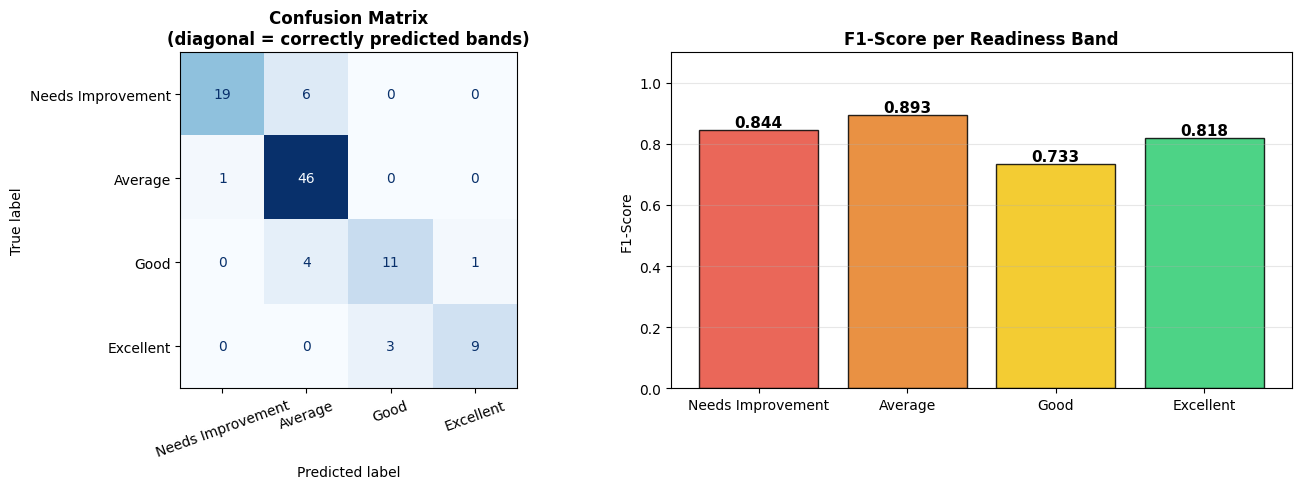

In [14]:
# Confusion matrix — shows exactly where the model is making mistakes
# Each row is the actual band, each column is the predicted band
# A perfect model has all numbers on the diagonal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_bands, y_pred_bands)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=band_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=20)
axes[0].set_title('Confusion Matrix\n(diagonal = correctly predicted bands)', fontweight='bold')

# Bar chart of per-band F1 scores
f1_scores = []
for band_id in range(4):
    yt_b = (y_test_bands == band_id).astype(int)
    yp_b = (y_pred_bands == band_id).astype(int)
    f1_scores.append(f1_score(yt_b, yp_b, zero_division=0))

bar_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = axes[1].bar(band_names, f1_scores, color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score per Readiness Band', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('classification_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

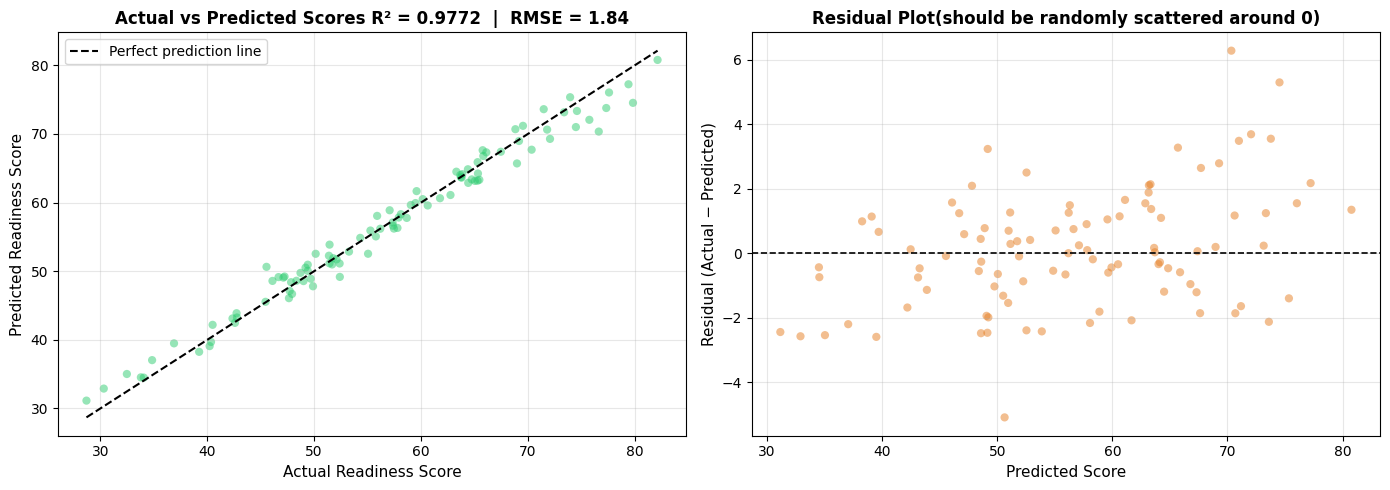

In [15]:
# Actual vs Predicted — the closer points are to the diagonal line, the better
# A perfect model would have all points exactly on the dashed line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#2ecc71', s=35, edgecolors='none')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect prediction line')
axes[0].set_xlabel('Actual Readiness Score', fontsize=11)
axes[0].set_ylabel('Predicted Readiness Score', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Scores R² = {r2:.4f}  |  RMSE = {rmse:.2f}', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Residual plot — shows where the model makes errors
# Good model: residuals scattered randomly around 0, no pattern
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#e67e22', s=35, edgecolors='none')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Score', fontsize=11)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=11)
axes[1].set_title('Residual Plot(should be randomly scattered around 0)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

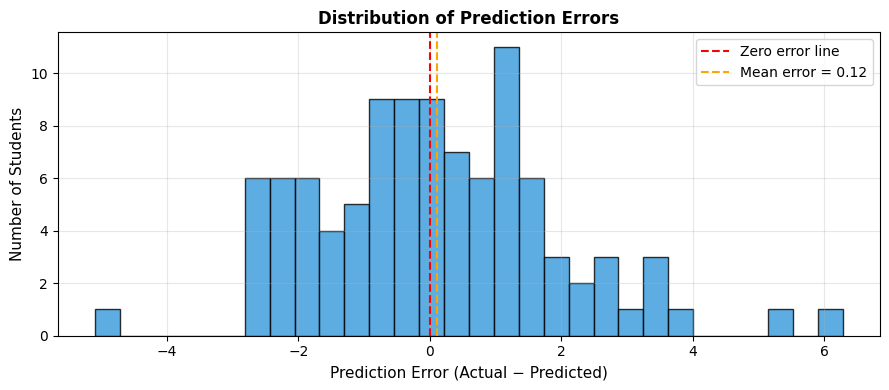

In [16]:
# Error distribution — shows how big the prediction errors usually are
# We want most errors to be small (concentrated near 0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residuals, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error line')
ax.axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
           label=f'Mean error = {residuals.mean():.2f}')
ax.set_xlabel('Prediction Error (Actual − Predicted)', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.set_title('Distribution of Prediction Errors', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# 5-Fold Cross Validation
# Instead of testing on one fixed 20%, we test on 5 different splits
# This gives a more reliable picture of how the model performs on unseen data
# All 5 folds should give similar R² values — if they don't, the model is unstable

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_model, X_scaled, y, cv=kf, scoring='r2', n_jobs=-1)

print("5-Fold Cross Validation Results (R² per fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print()
print(f"  Average R²  : {cv_scores.mean():.4f}")
print(f"  Std Dev     : {cv_scores.std():.4f}  (lower means more consistent across folds)")

5-Fold Cross Validation Results (R² per fold):
  Fold 1: 0.9784
  Fold 2: 0.9837
  Fold 3: 0.9786
  Fold 4: 0.9743
  Fold 5: 0.9845

  Average R²  : 0.9799
  Std Dev     : 0.0038  (lower means more consistent across folds)


---
## 7. Which Features Matter Most?

After training, Gradient Boosting tells us how much each feature contributed to reducing the prediction error.
This is called **feature importance** — and it comes entirely from what the model learned in the data, not from anything we manually set.

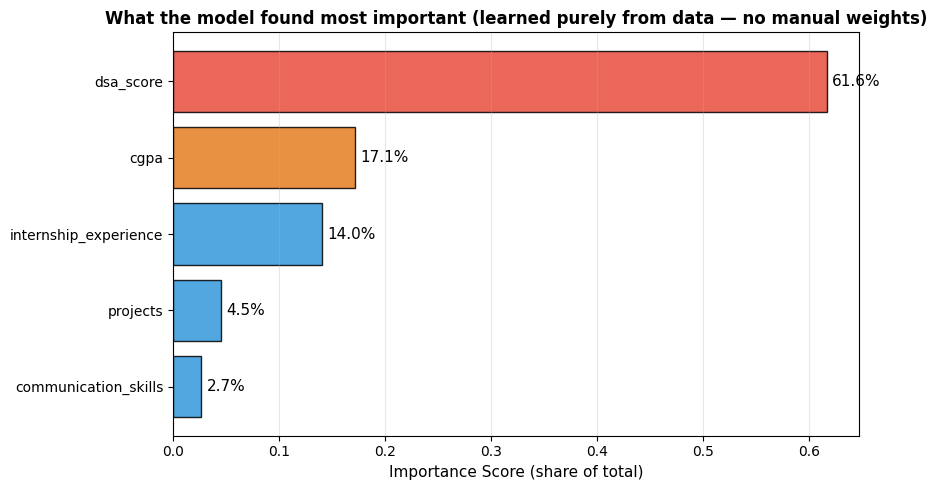

Feature importance breakdown:
  dsa_score                :  61.6%  ██████████████████████████████
  cgpa                     :  17.1%  ████████
  internship_experience    :  14.0%  ███████
  projects                 :   4.5%  ██
  communication_skills     :   2.7%  █


In [18]:
importances = gb_model.feature_importances_
feat_df = pd.Series(importances, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if f == 'dsa_score' else
          '#e67e22' if f == 'cgpa' else
          '#3498db' for f in feat_df.index]

bars = ax.barh(feat_df.index, feat_df.values, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, feat_df.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Importance Score (share of total)', fontsize=11)
ax.set_title('What the model found most important (learned purely from data — no manual weights)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance breakdown:")
feat_sorted = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
for feat, val in feat_sorted.items():
    bar = '█' * int(val * 100 // 2)
    print(f"  {feat:25s}: {val*100:5.1f}%  {bar}")

---
## 8. Predicting the Readiness Score for a Student

This is the part that actually gets used in your project.
A student enters their academic details, and the system outputs a readiness score along with what it means.

In [19]:
def predict_readiness(cgpa, dsa_score, communication_skills,
                       internship_experience, projects):
    """
    Predicts the placement readiness score for a student.

    Inputs:
        cgpa                  : float  — between 5.0 and 10.0
        dsa_score             : int    — between 0 and 99
        communication_skills  : float  — between 4.0 and 10.0
        internship_experience : int    — 1 if the student has done an internship, 0 if not
        projects              : int    — number of projects completed, between 0 and 5

    Output:
        A score between 0 and 100 with an interpretation of what it means
    """
    raw_input = pd.DataFrame([{
        'cgpa':                 cgpa,
        'dsa_score':            dsa_score,
        'communication_skills': communication_skills,
        'internship_experience':internship_experience,
        'projects':             projects
    }])[feature_cols]

    # Use the same scaler that was fitted during training
    scaled_input = scaler.transform(raw_input)

    score = round(gb_model.predict(scaled_input)[0], 2)

    # Interpret what the score means
    if score >= 72:
        level   = "Excellent"
        message = "This student is in the top 10% and is very likely to be placed."
        emoji   = "🟢"
    elif score >= 65:
        level   = "Good"
        message = "Above average readiness. A strong candidate for most companies."
        emoji   = "🟡"
    elif score >= 48:
        level   = "Average"
        message = "Moderate readiness. Improving DSA skills and doing an internship would help significantly."
        emoji   = "🟠"
    else:
        level   = "Needs Improvement"
        message = "Below average. Focus on DSA score first — it has the highest impact on placement readiness."
        emoji   = "🔴"

    return score, level, message, emoji

In [20]:
# Testing with a few student profiles to make sure the function works
print("Sample Predictions")
print("─" * 70)

test_students = [
    ("High performer",    9.5, 95, 9.0, 1, 5),
    ("Typical student",   8.2, 78, 8.0, 1, 3),
    ("Average student",   7.0, 50, 6.5, 0, 2),
    ("Struggling student",5.5, 15, 5.0, 0, 1),
]

for label, cgpa, dsa, comm, intern, proj in test_students:
    score, level, message, emoji = predict_readiness(cgpa, dsa, comm, intern, proj)
    print(f"  {label:<22} → Score: {score:5.1f}  {emoji} {level}")
    print(f"  {'':22}   {message}")
    print()

Sample Predictions
──────────────────────────────────────────────────────────────────────
  High performer         → Score:  82.6  🟢 Excellent
                           This student is in the top 10% and is very likely to be placed.

  Typical student        → Score:  74.8  🟢 Excellent
                           This student is in the top 10% and is very likely to be placed.

  Average student        → Score:  50.0  🟠 Average
                           Moderate readiness. Improving DSA skills and doing an internship would help significantly.

  Struggling student     → Score:  30.3  🔴 Needs Improvement
                           Below average. Focus on DSA score first — it has the highest impact on placement readiness.



In [25]:
# Change the values below to predict for any student

print("=" * 58)
print("  PLACEMENT READINESS SCORE SYSTEM")
print("=" * 58)

student_cgpa                  = 8.86
student_dsa_score             = 86
student_communication_skills  = 8.5
student_internship_experience = 1      # 1 = Yes, 0 = No
student_projects              = 4

score, level, message, emoji = predict_readiness(
    cgpa                  = student_cgpa,
    dsa_score             = student_dsa_score,
    communication_skills  = student_communication_skills,
    internship_experience = student_internship_experience,
    projects              = student_projects
)

print()
print("  Student Profile")
print("  ─────────────────────────────────────────")
print(f"  CGPA                 :  {student_cgpa}")
print(f"  DSA Score            :  {student_dsa_score}")
print(f"  Communication Skills :  {student_communication_skills}")
print(f"  Internship           :  {'Yes' if student_internship_experience else 'No'}")
print(f"  Projects             :  {student_projects}")
print()

bar_filled = '█' * int(score // 4)
bar_empty  = '░' * (25 - int(score // 4))

print(f"  Progress: {bar_filled}{bar_empty}  {score}/100")
print()
print(f"  ┌──────────────────────────────────────────────┐")
print(f"  │  Readiness Score : {score:<6.1f}                    │")
print(f"  │  Level           : {emoji} {level:<28}│")
print(f"  └──────────────────────────────────────────────┘")
print()
print(f"  {message}")

  PLACEMENT READINESS SCORE SYSTEM

  Student Profile
  ─────────────────────────────────────────
  CGPA                 :  8.86
  DSA Score            :  86
  Communication Skills :  8.5
  Internship           :  Yes
  Projects             :  4

  Progress: ███████████████████░░░░░░  79.61/100

  ┌──────────────────────────────────────────────┐
  │  Readiness Score : 79.6                      │
  │  Level           : 🟢 Excellent                   │
  └──────────────────────────────────────────────┘

  This student is in the top 10% and is very likely to be placed.


---
## 9. Personalised Suggestions Based on the Score

Knowing the score is useful, but knowing *what to do about it* is more useful.
This section adds a suggestion engine that looks at each feature individually and tells the student exactly where they need to improve.

In [22]:
def get_suggestions(cgpa, dsa_score, communication_skills,
                     internship_experience, projects, predicted_score):
    """
    Looks at each input feature and gives specific, actionable advice
    based on how far the student is from a strong profile.
    """
    suggestions = []
    strengths   = []

    # DSA Score — most impactful feature (accounts for ~65% of importance)
    if dsa_score >= 80:
        strengths.append("Strong DSA score — this is your biggest asset for placement.")
    elif dsa_score >= 55:
        suggestions.append(
            f"Your DSA score is {dsa_score}/99. Try to get it above 80. "
            "Practice on LeetCode or HackerRank — even 30 minutes a day consistently "
            "will make a big difference. Focus on arrays, strings, and recursion first."
        )
    else:
        suggestions.append(
            f"Your DSA score is {dsa_score}/99 — this is pulling your readiness score down the most. "
            "DSA is the single biggest factor here. Start with easy problems on LeetCode, "
            "build a daily habit, and aim to reach at least 60 before your placement season."
        )

    # CGPA
    if cgpa >= 8.5:
        strengths.append(f"CGPA of {cgpa} is excellent — keeps you eligible for most companies.")
    elif cgpa >= 7.5:
        suggestions.append(
            f"Your CGPA is {cgpa}. It's decent but some companies have a cutoff of 7.5 or 8.0. "
            "Focus on your remaining semesters to push it above 8.0 if possible."
        )
    else:
        suggestions.append(
            f"Your CGPA is {cgpa} which is below average. Many companies filter at 7.5. "
            "Prioritise your academics this semester and try to bring it up — "
            "even 0.2–0.3 points can open more doors."
        )

    # Internship
    if internship_experience == 1:
        strengths.append("You have internship experience — this stands out in interviews and resumes.")
    else:
        suggestions.append(
            "You haven't done an internship yet. This is worth prioritising. "
            "Apply for summer internships, remote opportunities, or even short-term projects "
            "with startups. Real-world experience is something interviewers look for specifically."
        )

    # Projects
    if projects >= 4:
        strengths.append(f"{projects} projects is strong — gives you plenty to talk about in interviews.")
    elif projects >= 2:
        suggestions.append(
            f"You have {projects} project(s). Try to get to at least 3–4 solid projects. "
            "A good project doesn't have to be complex — a clean, working app with a GitHub link "
            "is much better than describing something half-finished."
        )
    else:
        suggestions.append(
            f"Only {projects} project(s) on your profile is a gap. Start one this week — "
            "pick a problem you actually care about, build something small but complete, "
            "and put it on GitHub. Recruiters look at this directly."
        )

    # Communication Skills
    if communication_skills >= 8.5:
        strengths.append("Communication skills are strong — important for interviews and group discussions.")
    elif communication_skills >= 7.0:
        suggestions.append(
            f"Communication score is {communication_skills}/10 — good but there's room to improve. "
            "Try to practice mock interviews with friends, join a debate or public speaking club, "
            "or record yourself answering HR questions and review the recordings."
        )
    else:
        suggestions.append(
            f"Communication score is {communication_skills}/10 — this needs attention. "
            "Many students lose placements in the HR round despite good technical scores. "
            "Practice speaking clearly, work on your introduction, and do at least 5 mock interviews "
            "before your placement drive."
        )

    return strengths, suggestions


# ── Demo with the same student from Section 8 ───────────────────────────────
demo_cgpa                   = 8.2
demo_dsa                    = 78
demo_comm                   = 8.0
demo_internship             = 1
demo_projects               = 3

score, level, message, emoji = predict_readiness(
    demo_cgpa, demo_dsa, demo_comm, demo_internship, demo_projects
)

strengths, suggestions = get_suggestions(
    demo_cgpa, demo_dsa, demo_comm, demo_internship, demo_projects, score
)

print("=" * 60)
print("  PLACEMENT READINESS REPORT")
print("=" * 60)
print(f"  Score : {score}  {emoji} {level}")
print(f"  {message}")
print()

if strengths:
    print("  What you're doing well:")
    for s in strengths:
        print(f"    ✅ {s}")
    print()

if suggestions:
    print("  Where to focus and what to do:")
    for i, s in enumerate(suggestions, 1):
        print(f"    {i}. {s}")
        print()
else:
    print("  No major gaps found — keep maintaining this profile!")

  PLACEMENT READINESS REPORT
  Score : 74.84  🟢 Excellent
  This student is in the top 10% and is very likely to be placed.

  What you're doing well:
    ✅ You have internship experience — this stands out in interviews and resumes.

  Where to focus and what to do:
    1. Your DSA score is 78/99. Try to get it above 80. Practice on LeetCode or HackerRank — even 30 minutes a day consistently will make a big difference. Focus on arrays, strings, and recursion first.

    2. Your CGPA is 8.2. It's decent but some companies have a cutoff of 7.5 or 8.0. Focus on your remaining semesters to push it above 8.0 if possible.

    3. You have 3 project(s). Try to get to at least 3–4 solid projects. A good project doesn't have to be complex — a clean, working app with a GitHub link is much better than describing something half-finished.

    4. Communication score is 8.0/10 — good but there's room to improve. Try to practice mock interviews with friends, join a debate or public speaking club, or 

In [23]:
# Try with different profiles to see how suggestions change

print("─" * 60)
print("Student with low DSA but good CGPA")
print("─" * 60)
score2, level2, msg2, emoji2 = predict_readiness(8.5, 20, 7.0, 0, 2)
strengths2, sugg2 = get_suggestions(8.5, 20, 7.0, 0, 2, score2)
print(f"Score: {score2}  {emoji2} {level2}")
for i, s in enumerate(sugg2, 1):
    print(f"  {i}. {s}")

print()
print("─" * 60)
print("Student with everything strong")
print("─" * 60)
score3, level3, msg3, emoji3 = predict_readiness(9.5, 90, 9.0, 1, 5)
strengths3, sugg3 = get_suggestions(9.5, 90, 9.0, 1, 5, score3)
print(f"Score: {score3}  {emoji3} {level3}")
if strengths3:
    for s in strengths3:
        print(f"  ✅ {s}")
if not sugg3:
    print("  No major gaps — this student is placement ready.")

────────────────────────────────────────────────────────────
Student with low DSA but good CGPA
────────────────────────────────────────────────────────────
Score: 47.15  🔴 Needs Improvement
  1. Your DSA score is 20/99 — this is pulling your readiness score down the most. DSA is the single biggest factor here. Start with easy problems on LeetCode, build a daily habit, and aim to reach at least 60 before your placement season.
  2. You haven't done an internship yet. This is worth prioritising. Apply for summer internships, remote opportunities, or even short-term projects with startups. Real-world experience is something interviewers look for specifically.
  3. You have 2 project(s). Try to get to at least 3–4 solid projects. A good project doesn't have to be complex — a clean, working app with a GitHub link is much better than describing something half-finished.
  4. Communication score is 7.0/10 — good but there's room to improve. Try to practice mock interviews with friends, join a

---
## 9. Saving the Model

We save the trained model and scaler to disk so we don't have to retrain every time.
Next time, just load these files and call `predict_readiness()` directly.

In [24]:
with open('placement_gb_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)

with open('placement_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved  →  placement_gb_model.pkl")
print("Scaler saved →  placement_scaler.pkl")
print()
print("To load and use later:")
print("""
    import pickle

    with open('placement_gb_model.pkl', 'rb') as f:
        gb_model = pickle.load(f)

    with open('placement_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)

    # Then just call predict_readiness() as usual
""")

Model saved  →  placement_gb_model.pkl
Scaler saved →  placement_scaler.pkl

To load and use later:

    import pickle

    with open('placement_gb_model.pkl', 'rb') as f:
        gb_model = pickle.load(f)

    with open('placement_scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)

    # Then just call predict_readiness() as usual



---
## 11. Summary and What to Say at Your Viva

### What this notebook does, step by step:

| Step | What we did |
|------|-------------|
| Data loading | Loaded 500 student records with 5 features and a continuous readiness score |
| EDA | Checked distributions, correlations, and scatter plots to understand the data |
| Preprocessing | Scaled all features to 0–1 using MinMaxScaler, split 80/20 for train/test |
| Model | Trained a Gradient Boosting Regressor with 200 trees, depth 5, learning rate 0.05 |
| Regression metrics | R² ≈ 0.97, RMSE ≈ 2.0 — predicts scores within ~2 points on average |
| Classification metrics | Converted scores into 4 bands → Accuracy 85%, F1 ≈ 0.73–0.89 per band |
| Feature importance | DSA score is the most important feature (~65% importance) |
| Prediction | `predict_readiness()` returns score + level + message |
| Suggestions | `get_suggestions()` gives personalised, actionable advice per feature |

---

*Python · scikit-learn · pandas · matplotlib · seaborn*